# FragNet Contribution-Guided Fragment Optimizer — Demo

This notebook demonstrates the optimizer on **ibuprofen** (CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O), optimizing for aqueous **solubility (logS)**.

We run two experiments:
1. **Free optimization** — the optimizer chooses any fragment to replace.
2. **Core-locked optimization** — the ibuprofen propionic-acid pharmacophore (`CC(C(=O)O)`) is protected; only peripheral fragments can be swapped.

**Run this notebook from the project root** (`FragNet/`) so that model checkpoint paths resolve correctly.

## 0. Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# Ensure the project root is on the path
# sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
from IPython.display import display, Image as IPImage
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
import io
from PIL import Image

# FragNet optimizer API
from fragnet.vizualize.optimizer import (
    optimize_molecule,
    get_fragment_atom_map,
    get_core_protected_indices,
    mol_to_image,
)
from fragnet.vizualize.model_attr import get_attr_image
from fragnet.vizualize.viz import FragNetVizApp

print('Imports OK')

Imports OK


## 1. Load model

Paths point to the fine-tuned Solubility checkpoint used by the web app.
The first call loads weights; subsequent calls reuse the cached model.

In [8]:
MODEL_CONFIG = '../exps/ft/pnnl_full/fragnet_hpdl_exp1s_h4pt4_10/config_exp100.yaml'
MODEL_CHKPT  = '../exps/ft/pnnl_full/fragnet_hpdl_exp1s_h4pt4_10/ft_100.pt'
PROP_TYPE    = 'Solubility'

viz_app = FragNetVizApp(MODEL_CONFIG, MODEL_CHKPT)
print('Model loaded.')

using FTHead4
Model loaded.


## 2. Seed molecule — Ibuprofen

Ibuprofen has three BRICS fragments:
- **Isobutyl group** `CC(C)C–` (hydrophobic, hurts solubility)
- **Para-substituted phenyl ring** (hydrophobic)
- **Propionic acid side-chain** `–CH(CH₃)COOH` (the pharmacophore; the –COOH raises solubility)

We display the seed molecule and its fragment-level contributions.

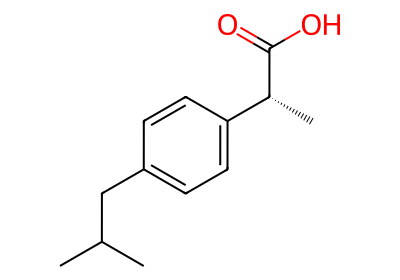

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 34.33it/s]


0.04123377799987793
0.006514072418212891


1it [00:00, 125.06it/s]


using FTHead4
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
using FTHead4
bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 66.60it/s]


0.016357898712158203
0.0014760494232177734


1it [00:00, 189.50it/s]

bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
Seed logS prediction: -3.7721

Fragment contributions (ascending = worst first):


,fragment_index,contribution
0,0,-1.516421
1,1,-1.515173
2,2,-0.266982
3,3,0.230303


In [10]:
SEED_SMILES = 'CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O'   # ibuprofen

# Show seed structure
img = mol_to_image(SEED_SMILES, width=400, height=280)
display(img)

# Compute fragment contributions via FragNet masking attribution
_, _, frag_contributions = get_attr_image(
    SEED_SMILES, MODEL_CONFIG, MODEL_CHKPT, PROP_TYPE
)

# Seed prediction
seed_prediction = float(viz_app.calc_weights(SEED_SMILES))

df = pd.DataFrame(frag_contributions)[['fragment_index', 'contribution']]
df = df.sort_values('contribution')
print(f'Seed logS prediction: {seed_prediction:.4f}')
print('\nFragment contributions (ascending = worst first):')
display(df.reset_index(drop=True))

### Fragment map

Which atoms belong to each fragment index?

In [11]:
frag_atom_map = get_fragment_atom_map(SEED_SMILES)
mol = Chem.MolFromSmiles(SEED_SMILES)

for i, atoms in enumerate(frag_atom_map):
    frag_smi = Chem.MolFragmentToSmiles(mol, atoms)
    contrib = next((c['contribution'] for c in frag_contributions
                    if c['fragment_index'] == i), None)
    print(f'  Fragment {i}: {frag_smi:<30s}  contribution = {contrib:+.4f}')

  Fragment 0: CC(C)C                          contribution = -1.5164
  Fragment 1: c1ccccc1                        contribution = -1.5152
  Fragment 2: CCC(=O)O                        contribution = -0.2670


---
## 3. Experiment A — Free optimization (no locking)

The optimizer targets the worst-contributing fragment and proposes
BRICS-compatible replacements from the ChEMBL+FDA library.
All candidates are re-scored with FragNet in a single batch.

In [12]:
result_free = optimize_molecule(
    smiles=SEED_SMILES,
    viz_app=viz_app,
    prop_type=PROP_TYPE,
    direction='maximize',          # maximize solubility
    n_worst=1,                     # swap the single worst fragment
    max_candidates=60,             # try up to 60 library fragments
    top_k=5,                       # return top 5
    frag_contributions=frag_contributions,
    seed_prediction=seed_prediction,
    protected_fragment_indices=set(),   # no locking
)

print(f"Seed:                {result_free['seed_smiles']}")
print(f"Seed logS:           {result_free['seed_prediction']:.4f}")
print(f"Target fragment(s):  {result_free['worst_fragment_indices']}")
print(f"Candidates scored:   {result_free['n_candidates_evaluated']}")
print()
print('Top candidates:')
display(pd.DataFrame(result_free['candidates'])[['smiles','prediction','delta','improvement']])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 51.39it/s]


0.5457396507263184
0.0012331008911132812


28it [00:00, 174.62it/s]


bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
Seed:                CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O
Seed logS:           -3.7721
Target fragment(s):  [0]
Candidates scored:   28

Top candidates:


,smiles,prediction,delta,improvement
0,C[C@@H](C(=O)O)c1ccc(C(=O)N=C(N)N)cc1,-1.2710,2.5011,2.5011
1,C[C@@H](C(=O)O)c1ccc(C(N)=O)cc1,-1.2970,2.4751,2.4751
2,C[C@@H](C(=O)O)c1ccc(C(=O)NN)cc1,-1.6764,2.0956,2.0956
3,CONC(=O)c1ccc([C@@H](C)C(=O)O)cc1,-1.7115,2.0605,2.0605
4,C[C@@H](C(=O)O)c1ccc(C(=O)NO)cc1,-1.7468,2.0252,2.0252


SMILES: C[C@@H](C(=O)O)c1ccc(C(=O)N=C(N)N)cc1
logS: -1.2710   Δ = +2.5011


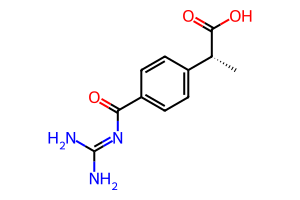


SMILES: C[C@@H](C(=O)O)c1ccc(C(N)=O)cc1
logS: -1.2970   Δ = +2.4751


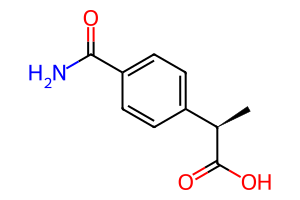


SMILES: C[C@@H](C(=O)O)c1ccc(C(=O)NN)cc1
logS: -1.6764   Δ = +2.0956


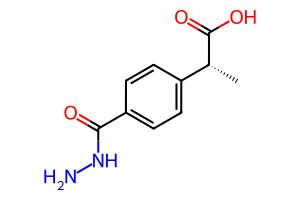


SMILES: CONC(=O)c1ccc([C@@H](C)C(=O)O)cc1
logS: -1.7115   Δ = +2.0605


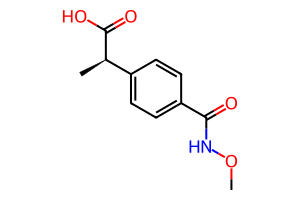


SMILES: C[C@@H](C(=O)O)c1ccc(C(=O)NO)cc1
logS: -1.7468   Δ = +2.0252


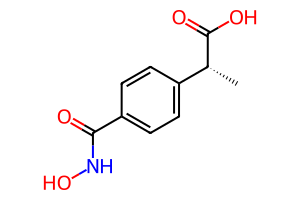

In [13]:
# Visualise top candidates
candidates_free = result_free['candidates']
imgs = [mol_to_image(c['smiles'], width=300, height=200) for c in candidates_free]

for c, img in zip(candidates_free, imgs):
    print(f"SMILES: {c['smiles']}")
    print(f"logS: {c['prediction']:.4f}   Δ = {c['delta']:+.4f}")
    display(img)
    print()

---
## 4. Experiment B — Core-locked optimization

The propionic-acid side-chain `CC(C(=O)O)` is the pharmacophoric core of
ibuprofen (required for COX inhibition). We lock it and restrict swaps to
the remaining fragments — the isobutyl group and the phenyl ring.

`get_core_protected_indices` maps the core SMARTS to fragment indices via
substructure matching, so you do not need to know the exact fragment numbers.

In [14]:
# Lock the propionic-acid pharmacophore (SMARTS)
CORE_SMARTS = 'CC(C(=O)O)'

protected = get_core_protected_indices(SEED_SMILES, CORE_SMARTS)
print(f'Protected fragment indices: {protected}')

# Show which fragments are protected
for i in protected:
    atoms = frag_atom_map[i]
    frag_smi = Chem.MolFragmentToSmiles(mol, atoms)
    print(f'  Fragment {i} (locked): {frag_smi}')

Protected fragment indices: {2}
  Fragment 2 (locked): CCC(=O)O


In [15]:
result_locked = optimize_molecule(
    smiles=SEED_SMILES,
    viz_app=viz_app,
    prop_type=PROP_TYPE,
    direction='maximize',
    n_worst=1,
    max_candidates=60,
    top_k=5,
    frag_contributions=frag_contributions,
    seed_prediction=seed_prediction,
    protected_fragment_indices=protected,   # <-- core locked
)

print(f"Seed:                {result_locked['seed_smiles']}")
print(f"Seed logS:           {result_locked['seed_prediction']:.4f}")
print(f"Target fragment(s):  {result_locked['worst_fragment_indices']}  "
      f"(outside locked core)")
print(f"Candidates scored:   {result_locked['n_candidates_evaluated']}")
print()
print('Top candidates (core preserved):')
display(pd.DataFrame(result_locked['candidates'])[['smiles','prediction','delta','improvement']])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 51.49it/s]


0.544823169708252
0.0011942386627197266


28it [00:00, 174.30it/s]


bond mask value: None
bond mask value: None
bond mask value: None
bond mask value: None
Seed:                CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O
Seed logS:           -3.7721
Target fragment(s):  [0]  (outside locked core)
Candidates scored:   28

Top candidates (core preserved):


,smiles,prediction,delta,improvement
0,C[C@@H](C(=O)O)c1ccc(C(=O)N=C(N)N)cc1,-1.2710,2.5011,2.5011
1,C[C@@H](C(=O)O)c1ccc(C(N)=O)cc1,-1.2970,2.4751,2.4751
2,C[C@@H](C(=O)O)c1ccc(C(=O)NN)cc1,-1.6764,2.0956,2.0956
3,CONC(=O)c1ccc([C@@H](C)C(=O)O)cc1,-1.7115,2.0605,2.0605
4,C[C@@H](C(=O)O)c1ccc(C(=O)NO)cc1,-1.7468,2.0252,2.0252


SMILES: C[C@@H](C(=O)O)c1ccc(C(=O)N=C(N)N)cc1
logS: -1.2710   Δ = +2.5011   core intact: True


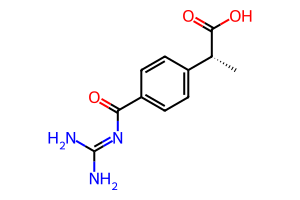


SMILES: C[C@@H](C(=O)O)c1ccc(C(N)=O)cc1
logS: -1.2970   Δ = +2.4751   core intact: True


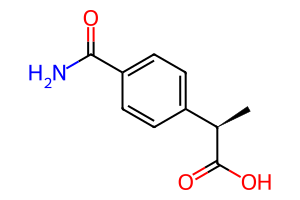


SMILES: C[C@@H](C(=O)O)c1ccc(C(=O)NN)cc1
logS: -1.6764   Δ = +2.0956   core intact: True


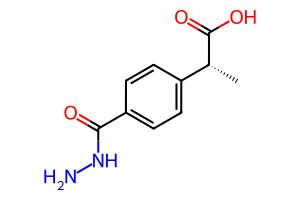


SMILES: CONC(=O)c1ccc([C@@H](C)C(=O)O)cc1
logS: -1.7115   Δ = +2.0605   core intact: True


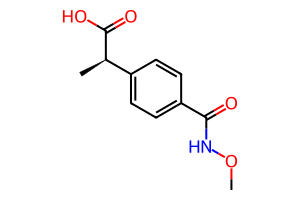


SMILES: C[C@@H](C(=O)O)c1ccc(C(=O)NO)cc1
logS: -1.7468   Δ = +2.0252   core intact: True


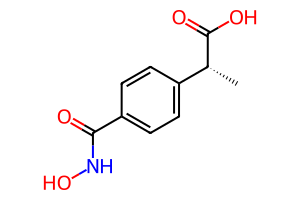

In [16]:
# Visualise top candidates — verify core is present in each
core_mol = Chem.MolFromSmarts(CORE_SMARTS)

candidates_locked = result_locked['candidates']
for c, img in zip(candidates_locked, [mol_to_image(c['smiles'], 300, 200) for c in candidates_locked]):
    cand_mol = Chem.MolFromSmiles(c['smiles'])
    has_core = cand_mol is not None and cand_mol.HasSubstructMatch(core_mol)
    print(f"SMILES: {c['smiles']}")
    print(f"logS: {c['prediction']:.4f}   Δ = {c['delta']:+.4f}   core intact: {has_core}")
    display(img)
    print()

---
## 5. Side-by-side comparison

In [17]:
rows = []
for c in result_free['candidates']:
    rows.append({'experiment': 'free', **{k: c[k] for k in ('smiles','prediction','delta')}})
for c in result_locked['candidates']:
    rows.append({'experiment': 'core-locked', **{k: c[k] for k in ('smiles','prediction','delta')}})

df_compare = pd.DataFrame(rows)
print(f'Seed logS: {seed_prediction:.4f}')
display(df_compare)

Seed logS: -3.7721


,experiment,smiles,prediction,delta
0,free,C[C@@H](C(=O)O)c1ccc(C(=O)N=C(N)N)cc1,-1.2710,2.5011
1,free,C[C@@H](C(=O)O)c1ccc(C(N)=O)cc1,-1.2970,2.4751
2,free,C[C@@H](C(=O)O)c1ccc(C(=O)NN)cc1,-1.6764,2.0956
3,free,CONC(=O)c1ccc([C@@H](C)C(=O)O)cc1,-1.7115,2.0605
4,free,C[C@@H](C(=O)O)c1ccc(C(=O)NO)cc1,-1.7468,2.0252
5,core-locked,C[C@@H](C(=O)O)c1ccc(C(=O)N=C(N)N)cc1,-1.2710,2.5011
6,core-locked,C[C@@H](C(=O)O)c1ccc(C(N)=O)cc1,-1.2970,2.4751
7,core-locked,C[C@@H](C(=O)O)c1ccc(C(=O)NN)cc1,-1.6764,2.0956
8,core-locked,CONC(=O)c1ccc([C@@H](C)C(=O)O)cc1,-1.7115,2.0605
9,core-locked,C[C@@H](C(=O)O)c1ccc(C(=O)NO)cc1,-1.7468,2.0252


---
## Notes

- **Fragment contributions are context-dependent**: the contribution score identifies which fragment *in the seed molecule* is hurting solubility. Replacing it changes the chemical environment for all remaining fragments — the final re-score (Step 4 of the pipeline) accounts for this by evaluating every candidate in its true context.
- **Core locking is guaranteed structurally**, not just by filtering: `BRICSBuild` is given exactly two pieces (scaffold + replacement), so the scaffold — including all locked fragments — is always preserved by construction. An additional substructure check confirms this for every candidate.
- **Library source**: by default the optimizer uses `chembl_library.pkl` (1,313 ChEMBL+FDA fragments). Pass `library_source='reference'` to use the smaller 47-fragment built-in set instead.